# Задание 3. Контурный анализ и бинаризация SAR-снимков
1. Найти наиболее протяженный участок (выделить линии при помощи преобразования Хафа)
2. Провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import copy


In [12]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

 # 1. Найти наиболее протяженный участок

Всего отрезков: 2
Самый длинный: 235.3 px, (15, 179) — (223, 69), наклон 27.9°


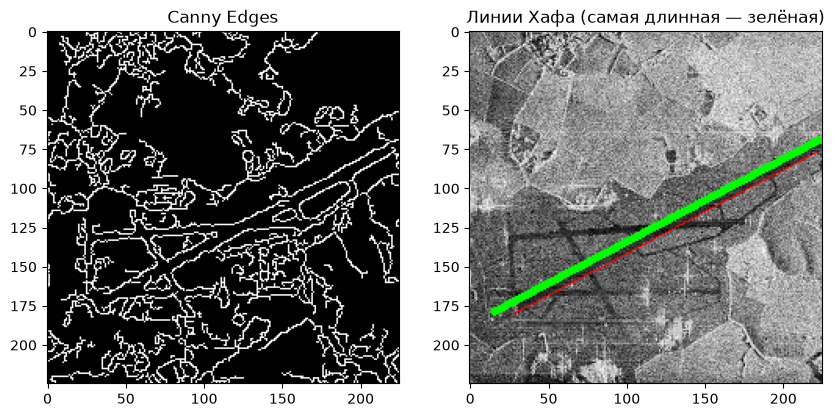

In [13]:
gray_f = cv2.medianBlur(image_gray, 5)
canny = cv2.Canny(gray_f, 50, 150, apertureSize=3)

lines = cv2.HoughLinesP(canny, rho=1, theta=np.pi / 180,
                        threshold=100, minLineLength=100, maxLineGap=20)

image_lines = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
max_length = 0
longest_line = None

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line.ravel()
        cv2.line(image_lines, (x1, y1), (x2, y2), (255, 0, 0), 1)

    for line in lines:
        x1, y1, x2, y2 = line.ravel()
        length = np.hypot(x2 - x1, y2 - y1)
        if length > max_length:
            max_length = length
            longest_line = (x1, y1, x2, y2)

    if longest_line is not None:
        x1, y1, x2, y2 = longest_line
        # зелёная — самая длинная линия
        cv2.line(image_lines, (x1, y1), (x2, y2), (0, 255, 0), 3)
        angle = math.degrees(math.atan2(-(y2 - y1), x2 - x1))
        print(f"Всего отрезков: {len(lines)}")
        print(f"Самый длинный: {max_length:.1f} px, ({x1}, {y1}) — ({x2}, {y2}), наклон {angle:.1f}°")
else:
    print("Отрезки не найдены — уменьшите threshold или minLineLength.")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Canny Edges")
plt.imshow(canny, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Линии Хафа (самая длинная — зелёная)")
plt.imshow(image_lines)
plt.show()


# 2. Исследование алгоритмов бинаризации и выделение дороги

In [14]:
T = 100
bin_img = copy.deepcopy(gray_f)
bin_img[gray_f > T] = 0
bin_img[gray_f <= T] = 255

# как доля тёмных пикселей зависит от порога
for t in (50, 75, 100, 125, 150):
    print(f"T = {t:3d}: доля белых = {np.count_nonzero(gray_f <= t) / gray_f.size:.4f}")


T =  50: доля белых = 0.0207
T =  75: доля белых = 0.0790
T = 100: доля белых = 0.2605
T = 125: доля белых = 0.4503
T = 150: доля белых = 0.6365


In [15]:
ret_otsu, th2 = cv2.threshold(gray_f, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print(f"Порог Оцу: {ret_otsu:.0f}")


Порог Оцу: 128


In [16]:
th3 = cv2.adaptiveThreshold(gray_f, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                            cv2.THRESH_BINARY_INV, 71, 21)


In [17]:
scale = 1
delta = 0
ddepth = cv2.CV_16S
grad_x = cv2.Sobel(image_gray, ddepth, 1, 0, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)
grad_y = cv2.Sobel(image_gray, ddepth, 0, 1, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)

abs_grad_x = cv2.convertScaleAbs(grad_x)
abs_grad_y = cv2.convertScaleAbs(grad_y)


In [18]:
masks = [(f"Глобальная (T={T})", bin_img),
         (f"Оцу (T={ret_otsu:.0f})", th2),
         ("Адаптивная", th3)]

for name, mask in masks:
    n, _ = cv2.connectedComponents(mask)
    print(f"{name}: доля белых = {np.count_nonzero(mask) / mask.size:.4f}, компонент = {n - 1}")


Глобальная (T=100): доля белых = 0.2605, компонент = 91
Оцу (T=128): доля белых = 0.4684, компонент = 83
Адаптивная: доля белых = 0.1291, компонент = 215


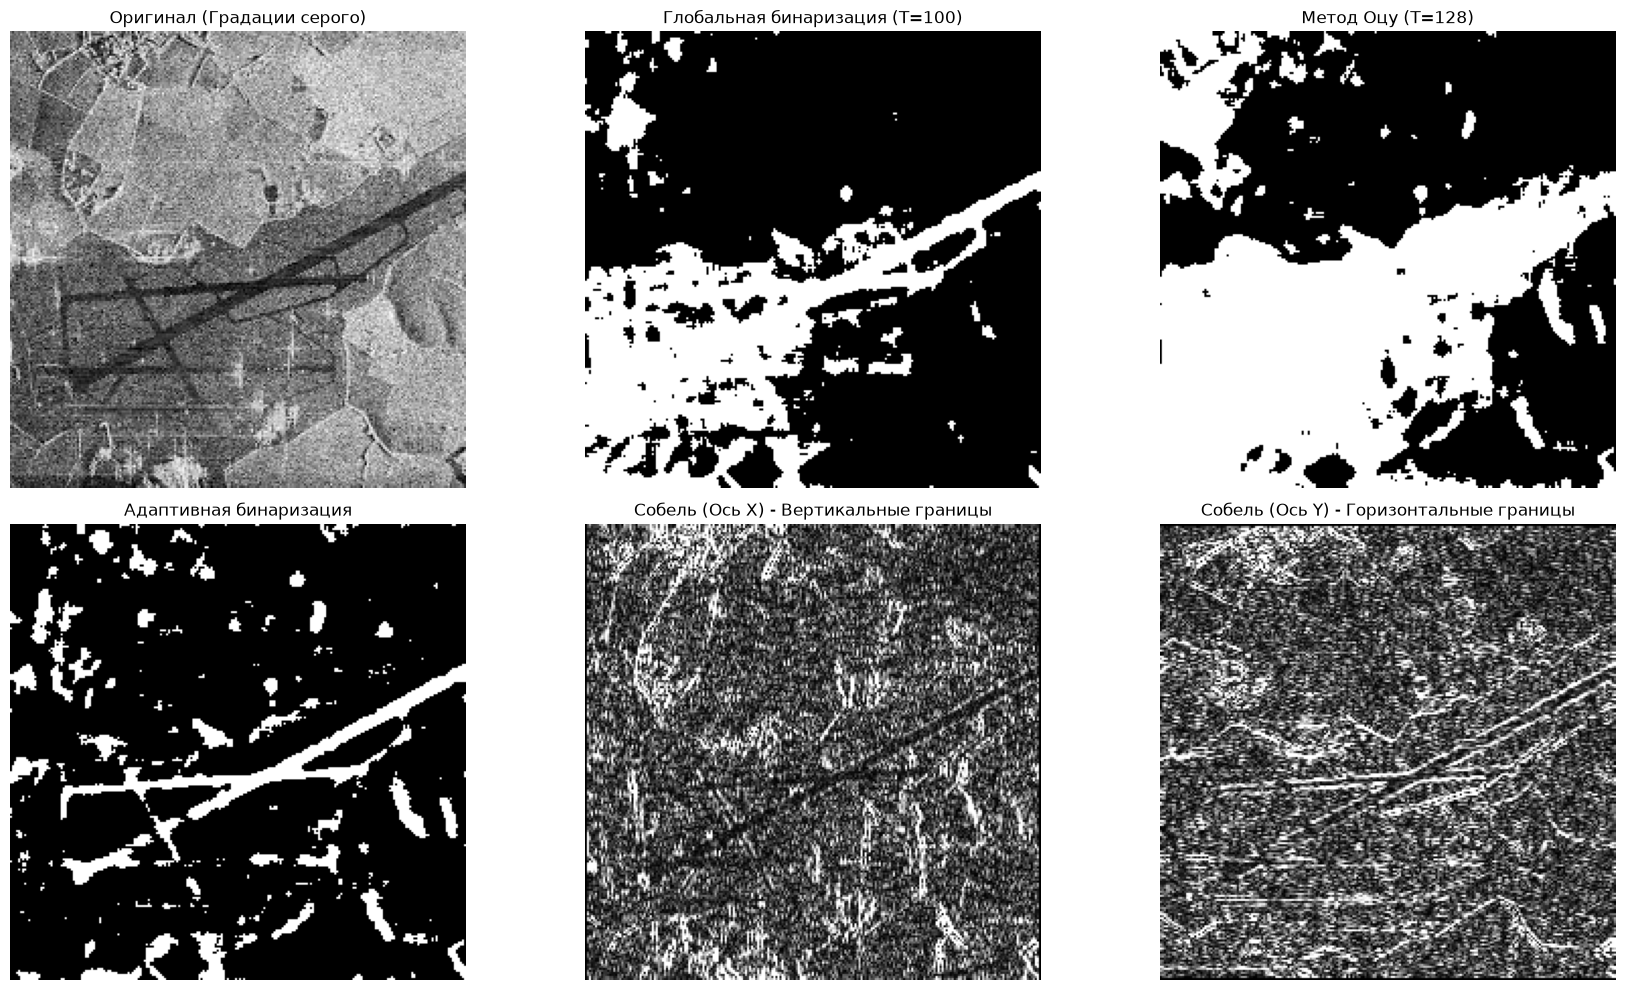

In [19]:
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.title("Оригинал (Градации серого)")
plt.imshow(image_gray, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title(f"Глобальная бинаризация (T={T})")
plt.imshow(bin_img, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title(f"Метод Оцу (T={ret_otsu:.0f})")
plt.imshow(th2, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Адаптивная бинаризация")
plt.imshow(th3, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Собель (Ось X) - Вертикальные границы")
plt.imshow(abs_grad_x, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("Собель (Ось Y) - Горизонтальные границы")
plt.imshow(abs_grad_y, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()


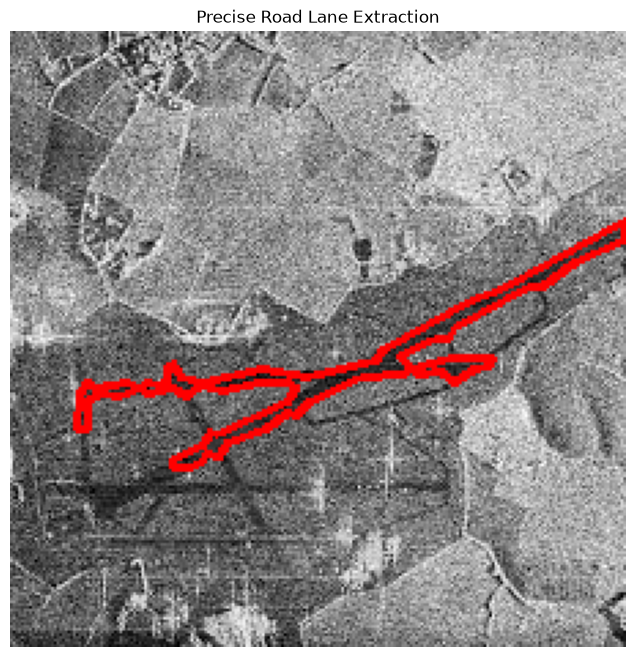

In [ ]:
# 1. Подавление спекл-шума (Медианный фильтр + Гаусс)
median = cv2.medianBlur(image_gray, 5)
blurred = cv2.GaussianBlur(median, (7, 7), 0)

# 2. Адаптивная бинаризация с инверсией
thresh = cv2.adaptiveThreshold(
    blurred, 
    255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 
    11, 
    2
)

# 3. Морфологическая очистка маски
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
clean_mask = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel)

# 4. Поиск контуров по очищенной маске
contours, _ = cv2.findContours(
    clean_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

lane_image = image.copy()


for c in contours:
    if cv2.contourArea(c) > 500:
        cv2.drawContours(
            lane_image, 
            [approx_contour], 
            -1, 
            (0, 0, 255), 
            2
        )

# Визуализация результата
plt.figure(figsize=(10, 8))

plt.imshow(cv2.cvtColor(lane_image, cv2.COLOR_BGR2RGB))
plt.title('Precise Road Lane Extraction')
plt.axis('off')

plt.show()

### Вывод
* **Задание 1.** Самый протяжённый линейный участок — 235.3 px, наклон 27.9°, координаты (15, 179) — (223, 69); он ложится на тёмную дорожную полосу на снимке.
* **Задание 2.** По чистоте маски лучший результат у метода Оцу: 83 компоненты связности против 91 у точечной бинаризации с фиксированным порогом и 215 у адаптивной.
* **Для выделения дорожной полосы лучше линейная (адаптивная) бинаризация.**
* **Полоса.** Взята адаптивная маска (окно 71, C = 21), уточнена размытием и повторной бинаризацией (окно 11, C = 2), после чего контуры площадью больше 500 обведены красным.
